## Analyse parameters and visualize statistics

Run this notebook after running StatisticsDataGeneration (sbl_benchmark_results.csv must exist).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/var/folders/2b/sj4wr6sn50jd9nt5d6hpb8l80000gn/T/ipykernel_58431/850387937.py:10: SyntaxWarning: invalid escape sequence '\e'
  lambda row: f"Cfg {int(row['Config_Idx'])}: $\eta$={row['Eta']}, $\epsilon$={row['Epsilon']}, G_Bias={row['Goal_Bias']}, R_Bias={row['Repair_Bias']}",
/var/folders/2b/sj4wr6sn50jd9nt5d6hpb8l80000gn/T/ipykernel_58431/850387937.py:10: SyntaxWarning: invalid escape sequence '\e'
  lambda row: f"Cfg {int(row['Config_Idx'])}: $\eta$={row['Eta']}, $\epsilon$={row['Epsilon']}, G_Bias={row['Goal_Bias']}, R_Bias={row['Repair_Bias']}",


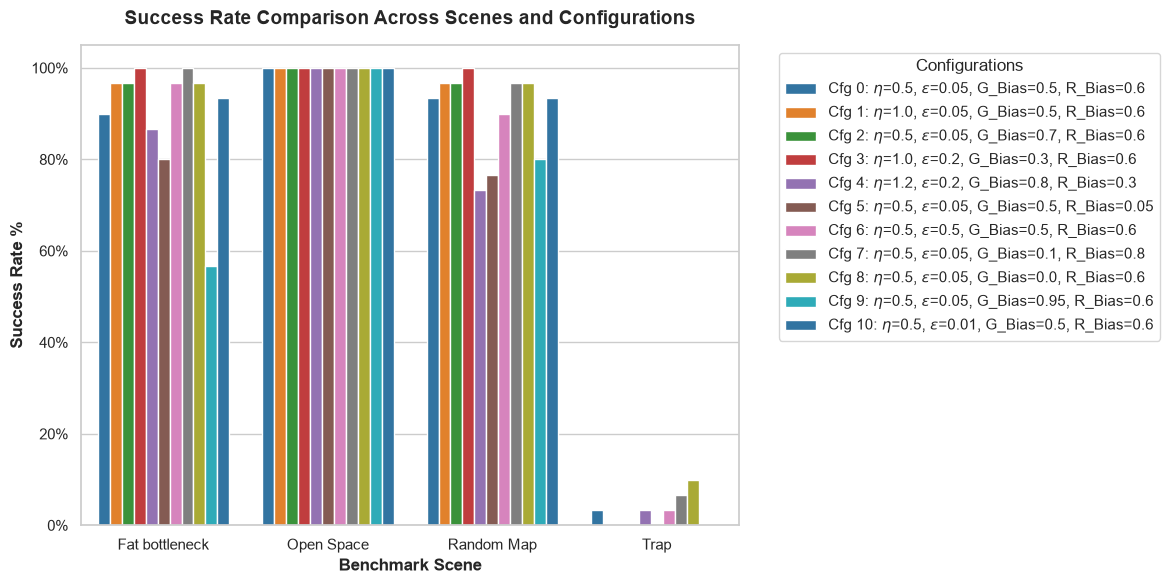

In [2]:
# 1. Load the saved data
df = pd.read_csv("sbl_benchmark_results.csv")

# 2. Calculate Success Rate
# Group by Scene and Config_Index, then take the mean of 'Success' (True=1, False=0)
success_df = df.groupby(["Scene", "Config_Idx", "Eta", "Epsilon", "Goal_Bias", "Repair_Bias"])["Success"].mean().reset_index()

# 3. Create a readable label string for each config to use in the legend
success_df["Config_Label"] = success_df.apply(
    lambda row: f"Cfg {int(row['Config_Idx'])}: $\eta$={row['Eta']}, $\epsilon$={row['Epsilon']}, G_Bias={row['Goal_Bias']}, R_Bias={row['Repair_Bias']}", 
    axis=1
)

# 4. Set up the plotting style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a bar plot using Seaborn
# x = Scene, y = Success Rate, hue = Config_Label
ax = sns.barplot(
    data=success_df, 
    x="Scene", 
    y="Success", 
    hue="Config_Label", 
    palette="tab10"
)

# 5. Graph formatting
plt.title("Success Rate Comparison Across Scenes and Configurations", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Benchmark Scene", fontsize=12, fontweight='bold')
plt.ylabel("Success Rate %", fontsize=12, fontweight='bold')
plt.ylim(0, 1.05) # Give a little room above 100% for the legend/labels

# Format y-axis as percentage
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Place the legend outside the plot area so it doesn't block the bars
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Configurations")

plt.tight_layout()
plt.show()

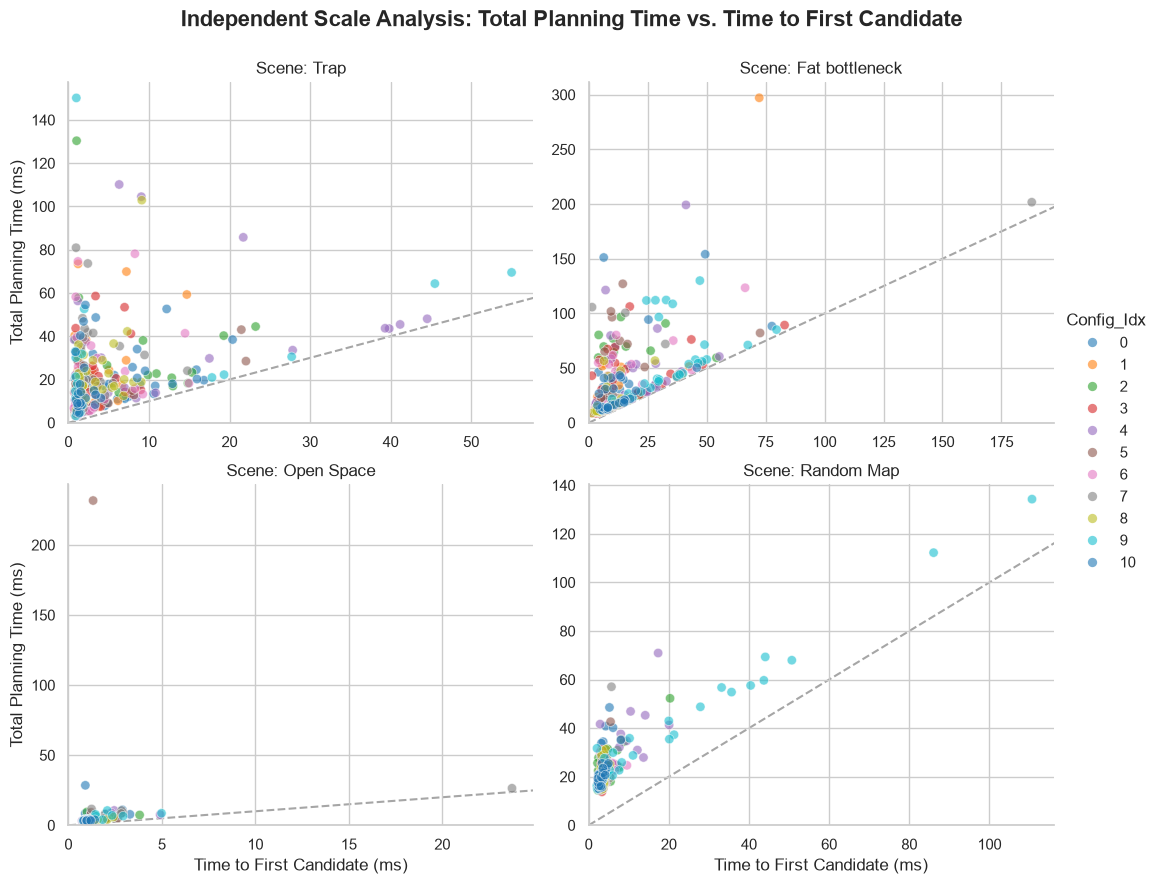

In [10]:
# Convert timing columns from seconds to milliseconds (ms) for a cleaner "zoomed-in" scale
df["Time_First_Candidate_ms"] = df["Time_First_Candidate"] * 1000
df["Plan_Time_ms"] = df["Plan_Time"] * 1000

# 2. Set up the plotting theme
sns.set_theme(style="whitegrid")

# 3. Create a 2x2 faceted scatterplot with independent axis scales (sharex=False, sharey=False)
g = sns.relplot(
    data=df,
    x="Time_First_Candidate_ms",
    y="Plan_Time_ms",
    col="Scene",
    col_wrap=2,             
    hue="Config_Idx",     
    palette="tab10",
    alpha=0.6,              
    s=45,                   
    height=4.5,
    aspect=1.2,
    facet_kws={"sharex": False, "sharey": False}
    )

# 4. Add a diagonal reference line (y = x) to every individual subplot based on its own local limits
for ax in g.axes.flat:
    x_max = ax.get_xlim()[1]
    y_max = ax.get_ylim()[1]
    
    lims = [0, max(x_max, y_max) * 1.05]
    ax.plot(lims, lims, color='gray', linestyle='--', alpha=0.7, zorder=0, label='y = x')
    
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)

# 5. Format labels and titles
g.set_axis_labels("Time to First Candidate (ms)", "Total Planning Time (ms)")
g.set_titles(col_template="Scene: {col_name}")

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Independent Scale Analysis: Total Planning Time vs. Time to First Candidate", fontsize=16, fontweight='bold')

plt.show()